# NGC4383 SFH and Stellar-Mass Check

Compare the new SFH/mass products from `9100/40 use` against the same-binning `7000/53` reference run.

Residual convention in this notebook: `9100/40 use - 7000/53 samebin`. For `E(B-V)` this is a direct color-excess difference; for `LOGMASS_SURFACE_DENSITY` this is a dex difference.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 160,
    'axes.grid': False,
    'font.size': 10,
})

root = Path('/Users/Igniz/Desktop/ICRAR/further')

RUNS = {
    'use': {
        'label': '9100/40 use',
        'path': root / 'v3tk_v7.6.8_VELSCALE40_use' / 'NGC4383',
        'sfh_file': 'NGC4383_sfh_maps.fits',
        'extended_file': 'NGC4383_spatial_binning_maps_extended.fits',
        'log_file': Path('mass_logs') / 'NGC4383.log',
    },
    'samebin': {
        'label': '7000/53 samebin',
        'path': root / 'v3tk_v7.6.8_7000_samebinning' / 'NGC4383',
        'sfh_file': 'NGC4383_sfh_maps.fits',
        'extended_file': 'NGC4383_spatial_binning_maps_extended.fits',
        'log_file': Path('mass_logs') / 'NGC4383.log',
    },
}

MAP_ORDER = ['use', 'samebin']
REF_KEY = 'samebin'
TEST_KEY = 'use'

PROPERTIES = {
    'EBV': {
        'label': 'E(B-V)',
        'file_key': 'sfh_file',
        'hdu': 'EBV',
        'unit': 'mag',
        'cmap': 'magma',
    },
    'LOGMASS_SURFACE_DENSITY': {
        'label': 'log stellar mass surface density',
        'file_key': 'extended_file',
        'hdu': 'LOGMASS_SURFACE_DENSITY',
        'unit': 'log10(M_sun/kpc^2)',
        'cmap': 'viridis',
    },
}

for run in RUNS.values():
    for key in ('sfh_file', 'extended_file'):
        path = run['path'] / run[key]
        if not path.exists():
            raise FileNotFoundError(path)
    log_path = run['path'] / run['log_file']
    if not log_path.exists():
        raise FileNotFoundError(log_path)

print('Configured runs:')
for key, run in RUNS.items():
    print(f"  {key:7s}: {run['label']} -> {run['path']}")

Configured runs:
  use    : 9100/40 use -> /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8_VELSCALE40_use/NGC4383
  samebin: 7000/53 samebin -> /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8_7000_samebinning/NGC4383


## Load Products And Check Shared Binning

In [2]:
def read_image(path, hdu):
    with fits.open(path, memmap=True) as hdul:
        if hdu not in hdul:
            names = [ext.name for ext in hdul]
            raise KeyError(f"HDU {hdu!r} not found in {path}. Available: {names}")
        data = np.array(hdul[hdu].data, dtype=float)
        header = hdul[hdu].header.copy()
    return data, header


def robust_limits(values, p=(2, 98), pad_fraction=0.04, fallback=(0.0, 1.0)):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return fallback
    lo, hi = np.nanpercentile(arr, p)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        center = np.nanmedian(arr)
        spread = np.nanstd(arr)
        if not np.isfinite(spread) or spread == 0:
            spread = 1.0
        lo, hi = center - spread, center + spread
    pad = (hi - lo) * pad_fraction
    return lo - pad, hi + pad


def symmetric_limits(values, p=98, fallback=(-1.0, 1.0)):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return fallback
    lim = np.nanpercentile(np.abs(arr), p)
    if not np.isfinite(lim) or lim == 0:
        lim = np.nanmax(np.abs(arr))
    if not np.isfinite(lim) or lim == 0:
        return fallback
    return -lim, lim


def finite_limits(values, fallback=(0.0, 1.0)):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return fallback
    lo = np.nanmin(arr)
    hi = np.nanmax(arr)
    if not np.isfinite(lo) or not np.isfinite(hi):
        return fallback
    if lo == hi:
        pad = max(abs(lo) * 0.01, 1e-6)
        return lo - pad, hi + pad
    return lo, hi


def as_common_nan_equal(a, b):
    return np.array_equal(np.isnan(a), np.isnan(b)) and np.array_equal(a[np.isfinite(a)], b[np.isfinite(b)])


data = {}
headers = {}
for run_key, run in RUNS.items():
    data[run_key] = {}
    headers[run_key] = {}
    binid, binid_header = read_image(run['path'] / run['extended_file'], 'BINID')
    data[run_key]['BINID'] = binid
    headers[run_key]['BINID'] = binid_header
    for prop_key, prop in PROPERTIES.items():
        path = run['path'] / run[prop['file_key']]
        arr, hdr = read_image(path, prop['hdu'])
        data[run_key][prop_key] = arr
        headers[run_key][prop_key] = hdr

shape_rows = []
for run_key, run in RUNS.items():
    for key in ['BINID', *PROPERTIES.keys()]:
        arr = data[run_key][key]
        shape_rows.append({
            'run': run['label'],
            'map': key,
            'shape': arr.shape,
            'finite_pixels': int(np.isfinite(arr).sum()),
            'min': np.nanmin(arr),
            'median': np.nanmedian(arr),
            'max': np.nanmax(arr),
        })
shape_summary = pd.DataFrame(shape_rows)
display(shape_summary)

binid_same = as_common_nan_equal(data[TEST_KEY]['BINID'], data[REF_KEY]['BINID'])
COMPARISON_BASIS = 'matched spatial bins' if binid_same else 'common finite pixels'
print(f"BINID maps exactly match including NaN mask: {binid_same}")
print(f"Comparison table basis: {COMPARISON_BASIS}")
print(f"Unique finite bins in {RUNS[TEST_KEY]['label']}: {np.unique(data[TEST_KEY]['BINID'][np.isfinite(data[TEST_KEY]['BINID'])]).size}")
print(f"Unique finite bins in {RUNS[REF_KEY]['label']}: {np.unique(data[REF_KEY]['BINID'][np.isfinite(data[REF_KEY]['BINID'])]).size}")

,run,map,shape,finite_pixels,min,median,max
0,9100/40 use,BINID,"(705, 633)",226640,0.000000,8613.000000,8737.000000
1,9100/40 use,EBV,"(705, 633)",226640,0.000000,0.024305,0.585124
2,9100/40 use,LOGMASS_SURFACE_DENSITY,"(705, 633)",226627,6.149341,7.225866,9.951754
3,7000/53 samebin,BINID,"(705, 633)",227455,0.000000,8547.000000,8686.000000
4,7000/53 samebin,EBV,"(705, 633)",227455,0.000000,0.024926,0.478217
5,7000/53 samebin,LOGMASS_SURFACE_DENSITY,"(705, 633)",227032,5.823107,7.074915,9.629667


BINID maps exactly match including NaN mask: False
Comparison table basis: common finite pixels
Unique finite bins in 9100/40 use: 8738
Unique finite bins in 7000/53 samebin: 8687


## E(B-V) And Stellar-Mass Maps

Each row uses one color scale shared by the two runs, so spatial differences are not hidden by independent normalization.

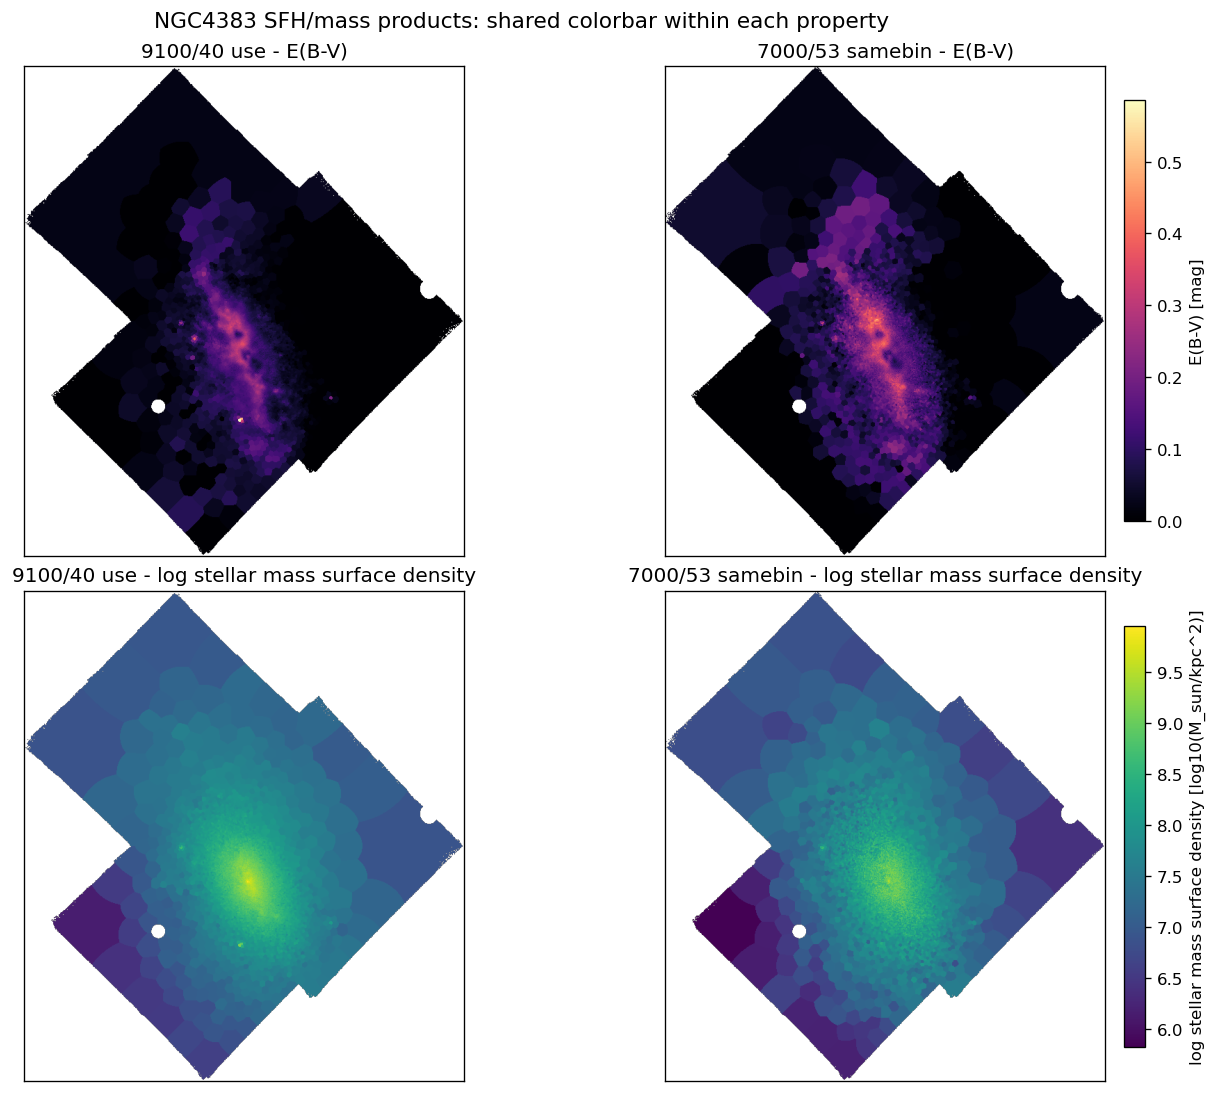

In [3]:
fig, axes = plt.subplots(len(PROPERTIES), len(MAP_ORDER), figsize=(11.5, 9.0), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(PROPERTIES.items()):
    combined = np.concatenate([data[run_key][prop_key].ravel() for run_key in MAP_ORDER])
    vmin, vmax = finite_limits(combined)
    last_im = None
    for col, run_key in enumerate(MAP_ORDER):
        ax = axes[row, col]
        im = ax.imshow(data[run_key][prop_key], origin='lower', cmap=prop['cmap'], vmin=vmin, vmax=vmax)
        last_im = im
        ax.set_title(f"{RUNS[run_key]['label']} - {prop['label']}")
        ax.set_xticks([])
        ax.set_yticks([])
    cbar = fig.colorbar(last_im, ax=axes[row, :], shrink=0.86, pad=0.015)
    cbar.set_label(f"{prop['label']} [{prop['unit']}]")

fig.suptitle('NGC4383 SFH/mass products: shared colorbar within each property', fontsize=13)
plt.show()

## Build Comparison Tables

When the two `BINID` maps match exactly, the comparison scatter/statistics use one row per spatial bin. When they do not match exactly, the helper falls back to one row per common finite pixel, so the pairwise plots and residual summaries still use the full overlapping map footprint. Residuals are always `9100/40 use - 7000/53 samebin`.

In [4]:
def per_bin_property_table(prop_key):
    test = data[TEST_KEY][prop_key]
    ref = data[REF_KEY][prop_key]
    test_bin = data[TEST_KEY]['BINID']
    ref_bin = data[REF_KEY]['BINID']

    if test.shape != ref.shape or test_bin.shape != ref_bin.shape:
        raise ValueError(f"Shape mismatch for {prop_key}: {test.shape} vs {ref.shape}")

    finite = np.isfinite(test) & np.isfinite(ref) & np.isfinite(test_bin) & np.isfinite(ref_bin)

    if binid_same:
        finite = finite & (test_bin == ref_bin)
        raw = pd.DataFrame({
            'binid_test': test_bin[finite].astype(int),
            'binid_ref': ref_bin[finite].astype(int),
            'test': test[finite],
            'ref': ref[finite],
        })
        grouped = raw.groupby('binid_test', sort=True).agg(
            binid_test=('binid_test', 'first'),
            binid_ref=('binid_ref', 'first'),
            test=('test', 'median'),
            ref=('ref', 'median'),
            n_pixels=('test', 'size'),
        ).reset_index(drop=True)
        grouped['comparison_unit'] = 'matched_bin'
    else:
        yy, xx = np.where(finite)
        grouped = pd.DataFrame({
            'binid_test': test_bin[finite].astype(int),
            'binid_ref': ref_bin[finite].astype(int),
            'x': xx,
            'y': yy,
            'test': test[finite],
            'ref': ref[finite],
            'n_pixels': 1,
            'comparison_unit': 'common_pixel',
        })

    grouped['residual'] = grouped['test'] - grouped['ref']
    grouped['prop_key'] = prop_key
    return grouped

comparison_tables = {prop_key: per_bin_property_table(prop_key) for prop_key in PROPERTIES}

for prop_key, table in comparison_tables.items():
    prop = PROPERTIES[prop_key]
    print(f"{prop['label']}: {len(table)} {COMPARISON_BASIS} represented")
    display_cols = ['binid_test', 'binid_ref', 'test', 'ref', 'residual', 'n_pixels', 'comparison_unit']
    if 'x' in table.columns and 'y' in table.columns:
        display_cols = ['x', 'y', *display_cols]
    display(table[display_cols].head())

E(B-V): 226609 common finite pixels represented


,x,y,binid_test,binid_ref,test,ref,residual,n_pixels,comparison_unit
0,257,2,8737,7223,0.004418,0.0,0.004418,1,common_pixel
1,258,2,8737,7223,0.004418,0.0,0.004418,1,common_pixel
2,256,3,8737,7223,0.004418,0.0,0.004418,1,common_pixel
3,257,3,8737,7223,0.004418,0.0,0.004418,1,common_pixel
4,258,3,8737,7223,0.004418,0.0,0.004418,1,common_pixel


log stellar mass surface density: 226600 common finite pixels represented


,x,y,binid_test,binid_ref,test,ref,residual,n_pixels,comparison_unit
0,257,2,8737,7223,6.602536,6.203642,0.398893,1,common_pixel
1,258,2,8737,7223,6.602536,6.203642,0.398893,1,common_pixel
2,256,3,8737,7223,6.602536,6.203642,0.398893,1,common_pixel
3,257,3,8737,7223,6.602536,6.203642,0.398893,1,common_pixel
4,258,3,8737,7223,6.602536,6.203642,0.398893,1,common_pixel


## Pairwise And Residual Scatter Plots

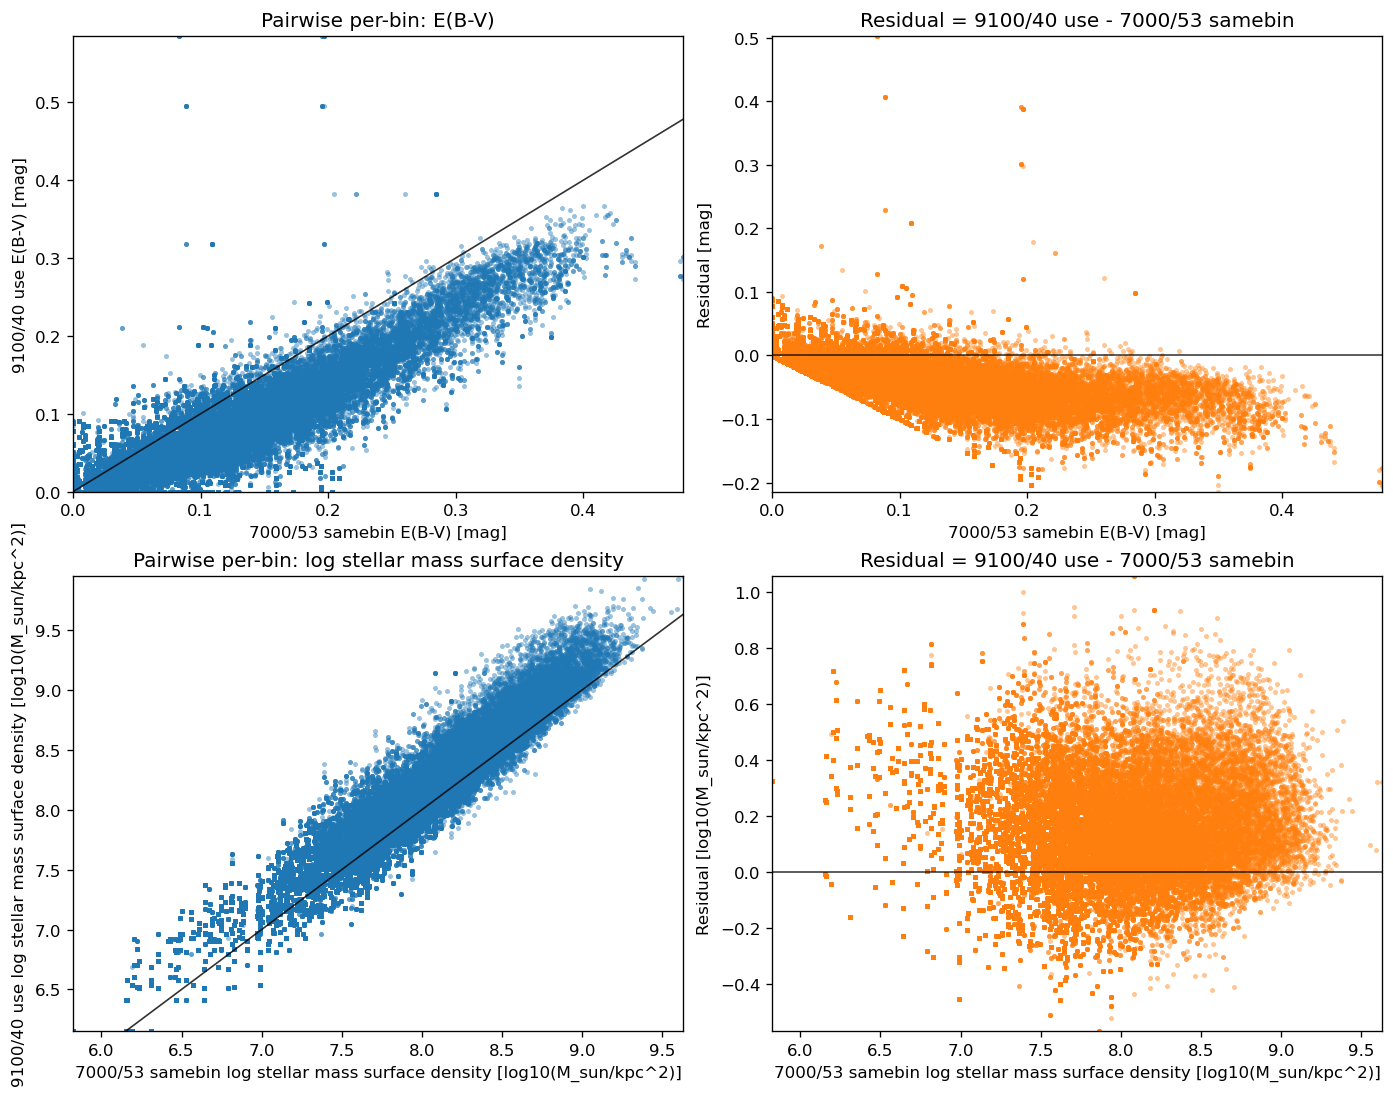

In [5]:
fig, axes = plt.subplots(len(PROPERTIES), 2, figsize=(11.5, 9.0), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(PROPERTIES.items()):
    table = comparison_tables[prop_key]
    x = table['ref'].to_numpy()
    y = table['test'].to_numpy()
    r = table['residual'].to_numpy()

    ax = axes[row, 0]
    ax.scatter(x, y, s=9, alpha=0.45, linewidths=0, color='tab:blue')
    xlo, xhi = finite_limits(x)
    ylo, yhi = finite_limits(y)
    line_lo = min(xlo, ylo)
    line_hi = max(xhi, yhi)
    ax.plot([line_lo, line_hi], [line_lo, line_hi], color='black', lw=1.0, alpha=0.8)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_ylabel(f"{RUNS[TEST_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_title(f"Pairwise per-bin: {prop['label']}")

    ax = axes[row, 1]
    ax.axhline(0, color='black', lw=1.0, alpha=0.75)
    ax.scatter(x, r, s=9, alpha=0.45, linewidths=0, color='tab:orange')
    ylo, yhi = finite_limits(r)
    xlo, xhi = finite_limits(x)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_ylabel(f"Residual [{prop['unit']}]")
    ax.set_title(f"Residual = {RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}")

plt.show()

## Residual Maps

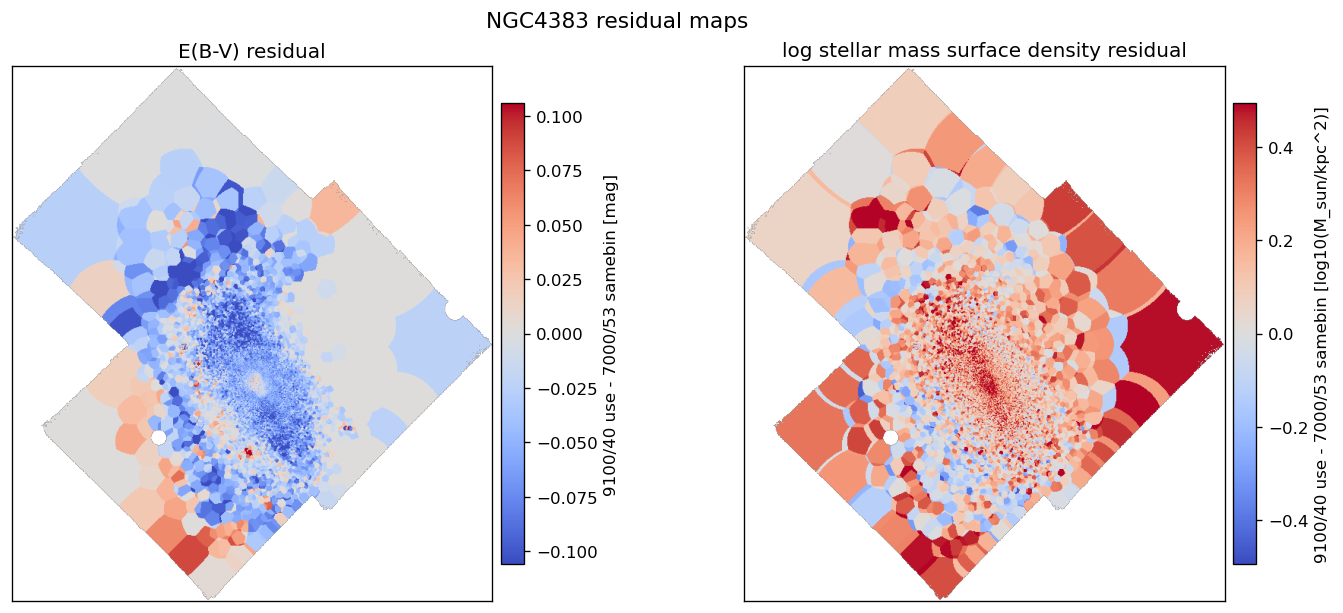

In [6]:
fig, axes = plt.subplots(1, len(PROPERTIES), figsize=(12.0, 5.0), constrained_layout=True)
if len(PROPERTIES) == 1:
    axes = [axes]

residual_maps = {}
for ax, (prop_key, prop) in zip(axes, PROPERTIES.items()):
    residual = data[TEST_KEY][prop_key] - data[REF_KEY][prop_key]
    residual_maps[prop_key] = residual
    vmin, vmax = symmetric_limits(residual)
    im = ax.imshow(residual, origin='lower', cmap='coolwarm', vmin=vmin, vmax=vmax)
    ax.set_title(f"{prop['label']} residual")
    ax.set_xticks([])
    ax.set_yticks([])
    cbar = fig.colorbar(im, ax=ax, shrink=0.86, pad=0.015)
    cbar.set_label(f"{RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']} [{prop['unit']}]")

fig.suptitle('NGC4383 residual maps', fontsize=13)
plt.show()

## Residual Summary Statistics

In [7]:
def nmad(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    med = np.nanmedian(values)
    return 1.4826 * np.nanmedian(np.abs(values - med))

summary_rows = []
for prop_key, prop in PROPERTIES.items():
    table = comparison_tables[prop_key]
    residual = table['residual'].to_numpy()
    summary_rows.append({
        'property': prop['label'],
        'unit': prop['unit'],
        'comparison_basis': COMPARISON_BASIS,
        'n_comparison_points': len(table),
        f"median_{RUNS[REF_KEY]['label']}": np.nanmedian(table['ref']),
        f"median_{RUNS[TEST_KEY]['label']}": np.nanmedian(table['test']),
        'median_residual_use_minus_samebin': np.nanmedian(residual),
        'mean_residual_use_minus_samebin': np.nanmean(residual),
        'nmad_residual': nmad(residual),
        'p16_residual': np.nanpercentile(residual, 16),
        'p84_residual': np.nanpercentile(residual, 84),
        'p02_residual': np.nanpercentile(residual, 2),
        'p98_residual': np.nanpercentile(residual, 98),
    })

residual_summary = pd.DataFrame(summary_rows)
display(residual_summary)

for _, row in residual_summary.iterrows():
    print(
        f"{row['property']}: median residual = {row['median_residual_use_minus_samebin']:.4g} "
        f"{row['unit']}, NMAD = {row['nmad_residual']:.4g} {row['unit']}"
    )

,property,unit,comparison_basis,n_comparison_points,median_7000/53 samebin,median_9100/40 use,median_residual_use_minus_samebin,mean_residual_use_minus_samebin,nmad_residual,p16_residual,p84_residual,p02_residual,p98_residual
0,E(B-V),mag,common finite pixels,226609,0.024926,0.024305,-0.011525,-0.018999,0.021830,-0.053212,0.001054,-0.105571,0.057749
1,log stellar mass surface density,log10(M_sun/kpc^2),common finite pixels,226600,7.074915,7.225866,0.139392,0.162506,0.199135,-0.018408,0.381073,-0.206231,0.494074


E(B-V): median residual = -0.01153 mag, NMAD = 0.02183 mag
log stellar mass surface density: median residual = 0.1394 log10(M_sun/kpc^2), NMAD = 0.1991 log10(M_sun/kpc^2)


## Largest Per-Bin Residuals

In [8]:
largest_residual_tables = {}
for prop_key, prop in PROPERTIES.items():
    table = comparison_tables[prop_key].copy()
    table['abs_residual'] = table['residual'].abs()
    table = table.sort_values('abs_residual', ascending=False).head(12)
    table = table.rename(columns={
        'test': RUNS[TEST_KEY]['label'],
        'ref': RUNS[REF_KEY]['label'],
    })
    largest_residual_tables[prop_key] = table
    print(f"Largest absolute residual bins: {prop['label']}")
    display(table[['binid_test', 'binid_ref', RUNS[TEST_KEY]['label'], RUNS[REF_KEY]['label'], 'residual', 'abs_residual', 'n_pixels']])

Largest absolute residual bins: E(B-V)


,binid_test,binid_ref,9100/40 use,7000/53 samebin,residual,abs_residual,n_pixels
39313,3664,3274,0.585124,0.082677,0.502447,0.502447,1
39314,3664,3274,0.585124,0.082677,0.502447,0.502447,1
38894,3664,3274,0.585124,0.082677,0.502447,0.502447,1
39735,3664,3274,0.585124,0.082677,0.502447,0.502447,1
39734,3664,3274,0.585124,0.082677,0.502447,0.502447,1
40588,3671,3386,0.495299,0.088534,0.406765,0.406765,1
39739,3671,3386,0.495299,0.088534,0.406765,0.406765,1
40587,3671,3386,0.495299,0.088534,0.406765,0.406765,1
40162,3671,3386,0.495299,0.088534,0.406765,0.406765,1
40163,3671,3386,0.495299,0.088534,0.406765,0.406765,1


Largest absolute residual bins: log stellar mass surface density


,binid_test,binid_ref,9100/40 use,7000/53 samebin,residual,abs_residual,n_pixels
38894,3664,3274,9.140191,8.082636,1.057555,1.057555,1
39735,3664,3274,9.140191,8.082636,1.057555,1.057555,1
39734,3664,3274,9.140191,8.082636,1.057555,1.057555,1
39314,3664,3274,9.140191,8.082636,1.057555,1.057555,1
39313,3664,3274,9.140191,8.082636,1.057555,1.057555,1
114475,7187,7097,8.385377,7.387294,0.998082,0.998082,1
90188,2480,2357,8.655590,7.710280,0.945310,0.945310,1
38896,3664,3378,9.140191,8.205424,0.934766,0.934766,1
38479,3664,3378,9.140191,8.205424,0.934766,0.934766,1
39316,3664,3378,9.140191,8.205424,0.934766,0.934766,1


## Mass-Log Total Properties

The mass logs contain integrated quantities and implementation notes. This parser keeps the comparison auditable by reading the log text directly.

In [9]:
LOG_PATTERNS = {
    'selected_ML_R_interpretation': r'Selected SFH-weight interpretation for ML_R:\s*(.+)',
    'total_R_mag_uncorrected_AB': r'Total R-band magnitude \(uncorrected\)\s*:\s*([-+0-9.eE]+)',
    'total_R_mag_corrected_AB': r'Total R-band magnitude \(corrected\)\s*:\s*([-+0-9.eE]+)',
    'total_R_luminosity_log10_Lsun': r'Total R-band luminosity\s*:\s*([-+0-9.eE]+)',
    'total_stellar_mass_log10_Msun': r'Total stellar mass \(R\)\s*:\s*([-+0-9.eE]+)',
    'integrated_ML_R_Msun_per_Lsun': r'Integrated stellar M/L_R\s*:\s*([-+0-9.eE]+)',
    'median_LOGMSTAR_ERR_dex': r'Median LOGMSTAR_ERR\s*:\s*([-+0-9.eE]+)',
    'median_LOGMASS_SURFACE_DENSITY_ERR_dex': r'Median LOGMASS_SURFACE_DENSITY_ERR:\s*([-+0-9.eE]+)',
    'inclination_correction': r'Inclination correction ([^:]+):\s*(.+)',
}


def parse_mass_log(path):
    text = Path(path).read_text(errors='replace')
    row = {}
    for key, pattern in LOG_PATTERNS.items():
        match = re.search(pattern, text)
        if not match:
            row[key] = np.nan
            continue
        if key == 'inclination_correction':
            row[key] = f"{match.group(1).strip()}: {match.group(2).strip()}"
        else:
            value = match.group(1).strip()
            try:
                row[key] = float(value)
            except ValueError:
                row[key] = value
    return row

log_rows = []
for run_key, run in RUNS.items():
    parsed = parse_mass_log(run['path'] / run['log_file'])
    parsed['run'] = run['label']
    parsed['log_path'] = str(run['path'] / run['log_file'])
    log_rows.append(parsed)

log_summary = pd.DataFrame(log_rows).set_index('run')
display(log_summary.T)

numeric_metrics = log_summary.select_dtypes(include=[np.number]).columns
log_delta = (log_summary.loc[RUNS[TEST_KEY]['label'], numeric_metrics] - log_summary.loc[RUNS[REF_KEY]['label'], numeric_metrics]).rename('use_minus_samebin')
display(log_delta.to_frame())

run,9100/40 use,7000/53 samebin
selected_ML_R_interpretation,light_v_to_r,light_v_to_r
total_R_mag_uncorrected_AB,11.842,11.842
total_R_mag_corrected_AB,11.445,11.302
total_R_luminosity_log10_Lsun,9.701,9.758
total_stellar_mass_log10_Msun,9.798,9.62
integrated_ML_R_Msun_per_Lsun,1.2494,0.7279
median_LOGMSTAR_ERR_dex,0.000243,0.000261
median_LOGMASS_SURFACE_DENSITY_ERR_dex,0.000243,0.000261
inclination_correction,ENABLED: applying b/a = 0.583 (adopting intrin...,ENABLED: applying b/a = 0.583 (adopting intrin...
log_path,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...


,use_minus_samebin
total_R_mag_uncorrected_AB,0.0
total_R_mag_corrected_AB,0.143
total_R_luminosity_log10_Lsun,-0.057
total_stellar_mass_log10_Msun,0.178
integrated_ML_R_Msun_per_Lsun,0.5215
median_LOGMSTAR_ERR_dex,-0.000019
median_LOGMASS_SURFACE_DENSITY_ERR_dex,-0.000019


## SFH Weight Grid Heatmaps

The `NGC4383_sfh_weights.fits` files store one normalized template-weight vector per spatial bin, and the `GRID` table gives the corresponding `LOGAGE`, `METAL`, and `ALPHA` values. Here the heatmap uses the equal-bin average weight on the age-metallicity grid, marginalizing over `ALPHA` if needed. The FITS grid stores age as `LOGAGE`, but the heatmap x-axis is labelled in linear age, `10**LOGAGE` Gyr, because that is easier to read. In these files `ALPHA` is constant at `0.0`, so the heatmap is effectively the native age-metallicity grid.

In [10]:
def read_sfh_weights(run_key):
    path = RUNS[run_key]['path'] / 'NGC4383_sfh_weights.fits'
    with fits.open(path, memmap=True) as hdul:
        weights = np.array(hdul['WEIGHTS'].data['WEIGHTS'], dtype=float)
        grid_data = hdul['GRID'].data
        grid = pd.DataFrame({name: np.array(grid_data[name], dtype=float) for name in grid_data.names})
    return weights, grid


def make_age_metal_weight_table(weights, grid):
    table = grid.copy()
    table['mean_weight'] = np.nanmean(weights, axis=0)
    total = table['mean_weight'].sum()
    if np.isfinite(total) and total > 0:
        table['mean_weight'] = table['mean_weight'] / total
    # If there were multiple alpha values, this would marginalize over alpha.
    return table.groupby(['LOGAGE', 'METAL'], as_index=False)['mean_weight'].sum()


def centers_to_edges(values):
    values = np.sort(np.asarray(values, dtype=float))
    if len(values) == 1:
        step = 0.5
        return np.array([values[0] - step, values[0] + step])
    mids = 0.5 * (values[:-1] + values[1:])
    first = values[0] - (mids[0] - values[0])
    last = values[-1] + (values[-1] - mids[-1])
    return np.concatenate([[first], mids, [last]])


def table_to_matrix(table, value_col='mean_weight'):
    logage_centers = np.sort(table['LOGAGE'].unique())
    age_centers_gyr = 10 ** logage_centers
    metals = np.sort(table['METAL'].unique())
    pivot = table.pivot(index='METAL', columns='LOGAGE', values=value_col).reindex(index=metals, columns=logage_centers)
    return age_centers_gyr, metals, pivot.to_numpy(dtype=float)


def summarize_weight_table(table):
    logage = table['LOGAGE'].to_numpy(dtype=float)
    age_gyr = 10 ** logage
    metal = table['METAL'].to_numpy(dtype=float)
    weight = table['mean_weight'].to_numpy(dtype=float)
    top = table.loc[table['mean_weight'].idxmax()]
    return {
        'mean_logage': np.sum(weight * logage),
        'mean_age_Gyr': np.sum(weight * age_gyr),
        'mean_metal': np.sum(weight * metal),
        'frac_age_lt_2Gyr': weight[age_gyr < 2].sum(),
        'frac_age_2_to_8Gyr': weight[(age_gyr >= 2) & (age_gyr < 8)].sum(),
        'frac_age_ge_8Gyr': weight[age_gyr >= 8].sum(),
        'frac_metal_lt_minus0p5': weight[metal < -0.5].sum(),
        'frac_metal_gt_minus0p25': weight[metal > -0.25].sum(),
        'top_LOGAGE': top['LOGAGE'],
        'top_age_Gyr': 10 ** top['LOGAGE'],
        'top_METAL': top['METAL'],
        'top_weight': top['mean_weight'],
    }

sfh_weights = {}
sfh_grids = {}
sfh_weight_tables = {}
for run_key in MAP_ORDER:
    weights, grid = read_sfh_weights(run_key)
    sfh_weights[run_key] = weights
    sfh_grids[run_key] = grid
    sfh_weight_tables[run_key] = make_age_metal_weight_table(weights, grid)
    print(
        f"{RUNS[run_key]['label']}: weights shape={weights.shape}, "
        f"row-sum median={np.nanmedian(weights.sum(axis=1)):.6f}, "
        f"LOGAGE bins={grid['LOGAGE'].nunique()}, METAL bins={grid['METAL'].nunique()}, ALPHA bins={grid['ALPHA'].nunique()}"
    )

same_template_grid = (
    sfh_grids[TEST_KEY].shape == sfh_grids[REF_KEY].shape
    and np.allclose(sfh_grids[TEST_KEY][['LOGAGE', 'METAL', 'ALPHA']], sfh_grids[REF_KEY][['LOGAGE', 'METAL', 'ALPHA']])
)
print(f"Template grids match exactly within numerical tolerance: {same_template_grid}")

sfh_weight_summary = pd.DataFrame({
    RUNS[run_key]['label']: summarize_weight_table(table)
    for run_key, table in sfh_weight_tables.items()
}).T
display(sfh_weight_summary)

merged_weight_grid = sfh_weight_tables[TEST_KEY].merge(
    sfh_weight_tables[REF_KEY],
    on=['LOGAGE', 'METAL'],
    suffixes=('_use', '_samebin'),
)
merged_weight_grid['age_Gyr'] = 10 ** merged_weight_grid['LOGAGE']
merged_weight_grid['residual_use_minus_samebin'] = merged_weight_grid['mean_weight_use'] - merged_weight_grid['mean_weight_samebin']

weight_grid_display_cols = ['age_Gyr', 'LOGAGE', 'METAL', 'mean_weight_use', 'mean_weight_samebin', 'residual_use_minus_samebin']
print('Largest positive age-metal weight residual cells:')
display(merged_weight_grid.sort_values('residual_use_minus_samebin', ascending=False)[weight_grid_display_cols].head(10))
print('Largest negative age-metal weight residual cells:')
display(merged_weight_grid.sort_values('residual_use_minus_samebin')[weight_grid_display_cols].head(10))

9100/40 use: weights shape=(8738, 477), row-sum median=1.000000, LOGAGE bins=53, METAL bins=9, ALPHA bins=1
7000/53 samebin: weights shape=(8687, 477), row-sum median=1.000000, LOGAGE bins=53, METAL bins=9, ALPHA bins=1
Template grids match exactly within numerical tolerance: True


,mean_logage,mean_age_Gyr,mean_metal,frac_age_lt_2Gyr,frac_age_2_to_8Gyr,frac_age_ge_8Gyr,frac_metal_lt_minus0p5,frac_metal_gt_minus0p25,top_LOGAGE,top_age_Gyr,top_METAL,top_weight
9100/40 use,0.397415,6.822442,-0.750824,0.372438,0.177071,0.450491,0.633385,0.363210,1.146128,14.00,-1.49,0.163426
7000/53 samebin,-0.148204,3.022235,-0.727530,0.637352,0.194197,0.168451,0.737038,0.190827,-1.154902,0.07,-0.66,0.071781


Largest positive age-metal weight residual cells:


,age_Gyr,LOGAGE,METAL,mean_weight_use,mean_weight_samebin,residual_use_minus_samebin
468,14.00,1.146128,-1.49,0.163426,0.003428,0.159998
53,0.08,-1.096910,0.26,0.130165,0.001165,0.129000
469,14.00,1.146128,-1.26,0.132697,0.004442,0.128255
244,2.75,0.439333,-1.26,0.048450,0.000340,0.048110
196,1.25,0.096910,0.15,0.058546,0.017183,0.041363
388,9.50,0.977724,-1.26,0.046196,0.012553,0.033643
361,8.00,0.903090,-1.26,0.034096,0.011062,0.023034
100,0.30,-0.522879,-1.26,0.019315,0.000422,0.018893
79,0.15,-0.823909,0.15,0.017130,0.000651,0.016479
334,6.50,0.812913,-1.26,0.020159,0.006331,0.013828


Largest negative age-metal weight residual cells:


,age_Gyr,LOGAGE,METAL,mean_weight_use,mean_weight_samebin,residual_use_minus_samebin
39,0.07,-1.154902,-0.66,1.091276e-05,0.071781,-0.071770
92,0.25,-0.602060,-0.96,2.838575e-03,0.041330,-0.038491
56,0.09,-1.045757,-0.96,0.000000e+00,0.034250,-0.034250
74,0.15,-0.823909,-0.96,1.675742e-07,0.022208,-0.022208
30,0.06,-1.221849,-0.66,1.257778e-05,0.021032,-0.021020
219,2.00,0.301030,-0.66,2.605678e-04,0.020995,-0.020735
397,10.00,1.000000,-1.26,1.380283e-02,0.034323,-0.020520
65,0.10,-1.000000,-0.96,0.000000e+00,0.019429,-0.019429
218,2.00,0.301030,-0.96,7.500931e-04,0.018657,-0.017907
201,1.50,0.176091,-0.66,4.542811e-04,0.018180,-0.017725


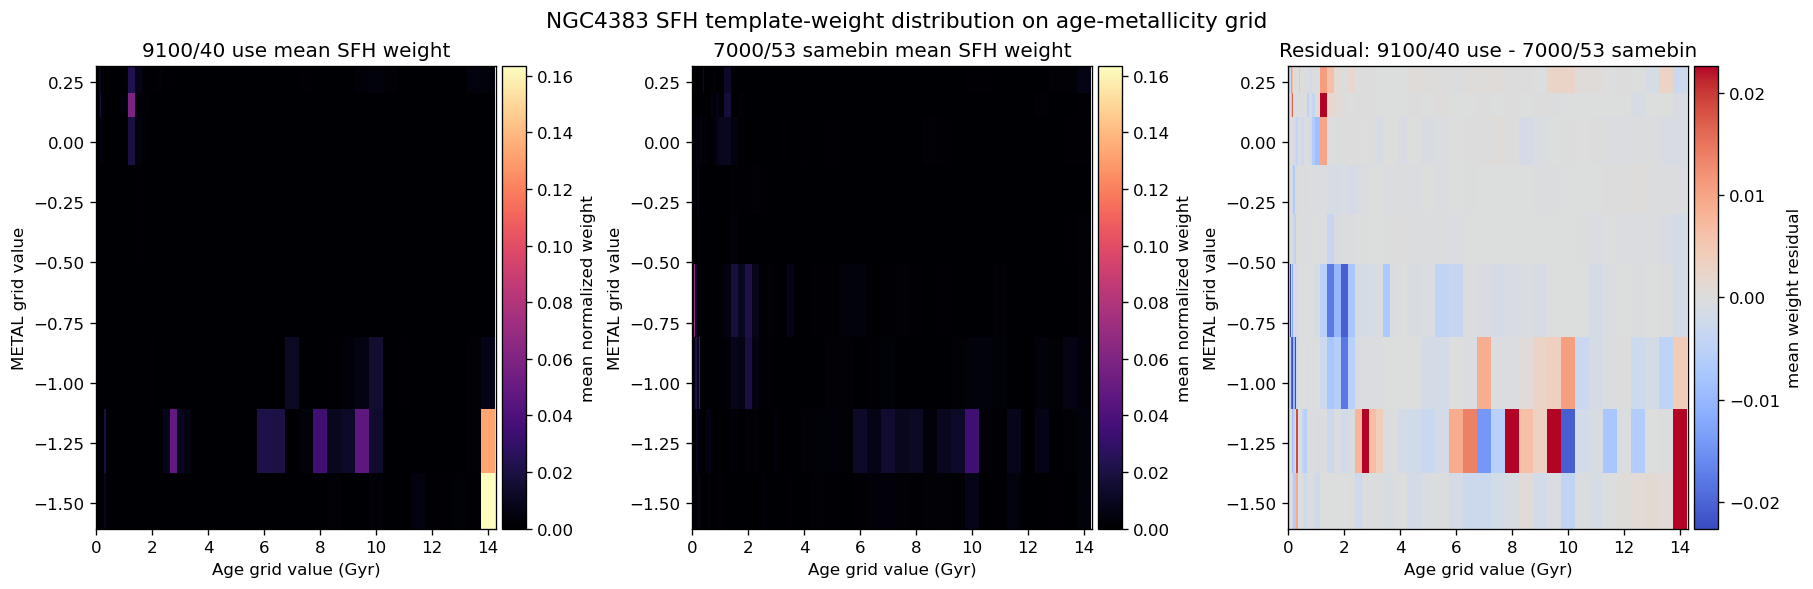

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), constrained_layout=True)

matrices = {}
for run_key in MAP_ORDER:
    age_centers_gyr, metals, matrix = table_to_matrix(sfh_weight_tables[run_key])
    matrices[run_key] = matrix
age_edges = centers_to_edges(age_centers_gyr)
metal_edges = centers_to_edges(metals)
shared_vmax = np.nanmax(np.concatenate([matrices[run_key].ravel() for run_key in MAP_ORDER]))
if not np.isfinite(shared_vmax) or shared_vmax <= 0:
    shared_vmax = 1.0

for ax, run_key in zip(axes[:2], MAP_ORDER):
    im = ax.pcolormesh(age_edges, metal_edges, matrices[run_key], cmap='magma', vmin=0, vmax=shared_vmax, shading='auto')
    ax.set_title(f"{RUNS[run_key]['label']} mean SFH weight")
    ax.set_xlabel('Age grid value (Gyr)')
    ax.set_ylabel('METAL grid value')
    ax.set_xlim(0, np.nanmax(age_centers_gyr) * 1.02)
    ax.set_xticks([0, 2, 4, 6, 8, 10, 12, 14])
    fig.colorbar(im, ax=ax, pad=0.01, label='mean normalized weight')

residual_matrix = matrices[TEST_KEY] - matrices[REF_KEY]
rmin, rmax = symmetric_limits(residual_matrix)
im = axes[2].pcolormesh(age_edges, metal_edges, residual_matrix, cmap='coolwarm', vmin=rmin, vmax=rmax, shading='auto')
axes[2].set_title(f"Residual: {RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}")
axes[2].set_xlabel('Age grid value (Gyr)')
axes[2].set_ylabel('METAL grid value')
axes[2].set_xlim(0, np.nanmax(age_centers_gyr) * 1.02)
axes[2].set_xticks([0, 2, 4, 6, 8, 10, 12, 14])
fig.colorbar(im, ax=axes[2], pad=0.01, label='mean weight residual')

fig.suptitle('NGC4383 SFH template-weight distribution on age-metallicity grid', fontsize=13)
plt.show()

## SFH Age And Metallicity Map Diagnostics

The previous heatmap collapses the galaxy to an average template-weight distribution. These panels check whether the fitted `AGE` and `METAL` image products show the same kind of run-to-run shift spatially. Residuals are again `9100/40 use - 7000/53 samebin`. The pairwise tables use matched spatial bins when the two `BINID` maps are identical, otherwise common finite pixels.

,property,unit,comparison_basis,n_comparison_points,median_7000/53 samebin,median_9100/40 use,median_residual_use_minus_samebin,mean_residual_use_minus_samebin,nmad_residual,p16_residual,p84_residual,corrcoef,n_positive_residual,n_negative_residual
0,SFH age,Gyr,common finite pixels,226609,4.986405,10.354134,3.617083,3.792825,3.265314,0.768104,7.104772,0.709685,206468,20141
1,SFH metallicity,dex,common finite pixels,226609,-0.871716,-0.983647,-0.131219,-0.101244,0.169534,-0.282545,0.061911,0.796112,55357,171236


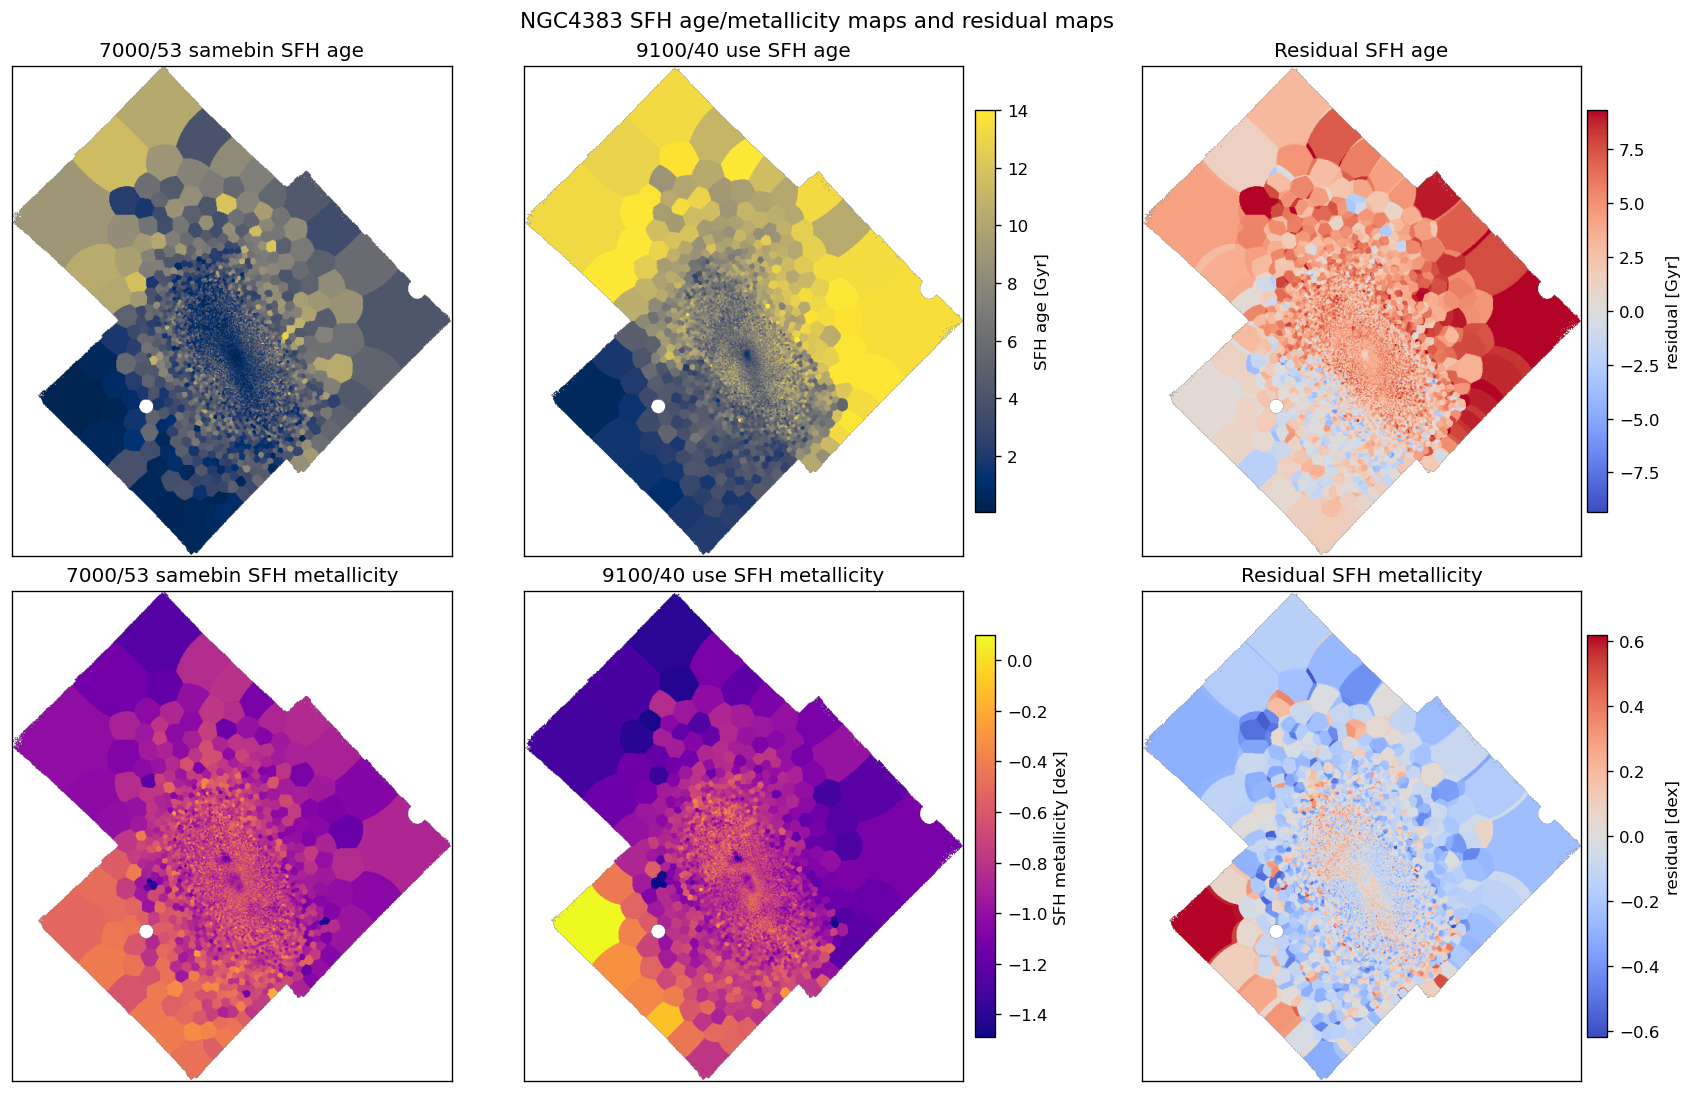

In [12]:
SFH_MAP_PROPERTIES = {
    'AGE': {
        'label': 'SFH age',
        'unit': 'Gyr',
        'cmap': 'cividis',
    },
    'METAL': {
        'label': 'SFH metallicity',
        'unit': 'dex',
        'cmap': 'plasma',
    },
}

sfh_map_data = {run_key: {} for run_key in MAP_ORDER}
for run_key in MAP_ORDER:
    sfh_path = RUNS[run_key]['path'] / RUNS[run_key]['sfh_file']
    for prop_key in SFH_MAP_PROPERTIES:
        sfh_map_data[run_key][prop_key], _ = read_image(sfh_path, prop_key)


def per_bin_sfh_map_table(prop_key):
    test = sfh_map_data[TEST_KEY][prop_key]
    ref = sfh_map_data[REF_KEY][prop_key]
    test_bin = data[TEST_KEY]['BINID']
    ref_bin = data[REF_KEY]['BINID']
    finite = np.isfinite(test) & np.isfinite(ref) & np.isfinite(test_bin) & np.isfinite(ref_bin)

    if binid_same:
        finite = finite & (test_bin == ref_bin)
        raw = pd.DataFrame({
            'binid': test_bin[finite].astype(int),
            'test': test[finite],
            'ref': ref[finite],
        })
        grouped = raw.groupby('binid', sort=True).agg(
            test=('test', 'median'),
            ref=('ref', 'median'),
            n_pixels=('test', 'size'),
        ).reset_index()
        grouped['comparison_unit'] = 'matched_bin'
    else:
        yy, xx = np.where(finite)
        grouped = pd.DataFrame({
            'x': xx,
            'y': yy,
            'binid_test': test_bin[finite].astype(int),
            'binid_ref': ref_bin[finite].astype(int),
            'test': test[finite],
            'ref': ref[finite],
            'n_pixels': 1,
            'comparison_unit': 'common_pixel',
        })

    grouped['residual'] = grouped['test'] - grouped['ref']
    return grouped

sfh_map_tables = {prop_key: per_bin_sfh_map_table(prop_key) for prop_key in SFH_MAP_PROPERTIES}

sfh_map_summary_rows = []
for prop_key, prop in SFH_MAP_PROPERTIES.items():
    table = sfh_map_tables[prop_key]
    residual = table['residual'].to_numpy(dtype=float)
    sfh_map_summary_rows.append({
        'property': prop['label'],
        'unit': prop['unit'],
        'comparison_basis': COMPARISON_BASIS,
        'n_comparison_points': len(table),
        f"median_{RUNS[REF_KEY]['label']}": np.nanmedian(table['ref']),
        f"median_{RUNS[TEST_KEY]['label']}": np.nanmedian(table['test']),
        'median_residual_use_minus_samebin': np.nanmedian(residual),
        'mean_residual_use_minus_samebin': np.nanmean(residual),
        'nmad_residual': nmad(residual),
        'p16_residual': np.nanpercentile(residual, 16),
        'p84_residual': np.nanpercentile(residual, 84),
        'corrcoef': np.corrcoef(table['ref'], table['test'])[0, 1],
        'n_positive_residual': int((residual > 0).sum()),
        'n_negative_residual': int((residual < 0).sum()),
    })

sfh_map_summary = pd.DataFrame(sfh_map_summary_rows)
display(sfh_map_summary)

fig, axes = plt.subplots(len(SFH_MAP_PROPERTIES), 3, figsize=(14.5, 9.0), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(SFH_MAP_PROPERTIES.items()):
    ref = sfh_map_data[REF_KEY][prop_key]
    test = sfh_map_data[TEST_KEY][prop_key]
    combined = np.concatenate([ref.ravel(), test.ravel()])
    vmin, vmax = finite_limits(combined)

    im0 = axes[row, 0].imshow(ref, origin='lower', cmap=prop['cmap'], vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"{RUNS[REF_KEY]['label']} {prop['label']}")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    im1 = axes[row, 1].imshow(test, origin='lower', cmap=prop['cmap'], vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"{RUNS[TEST_KEY]['label']} {prop['label']}")
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])
    fig.colorbar(im1, ax=axes[row, :2], shrink=0.82, pad=0.012, label=f"{prop['label']} [{prop['unit']}]")

    residual = test - ref
    rmin, rmax = symmetric_limits(residual)
    im2 = axes[row, 2].imshow(residual, origin='lower', cmap='coolwarm', vmin=rmin, vmax=rmax)
    axes[row, 2].set_title(f"Residual {prop['label']}")
    axes[row, 2].set_xticks([])
    axes[row, 2].set_yticks([])
    fig.colorbar(im2, ax=axes[row, 2], shrink=0.82, pad=0.012, label=f"residual [{prop['unit']}]")

fig.suptitle('NGC4383 SFH age/metallicity maps and residual maps', fontsize=13)
plt.show()

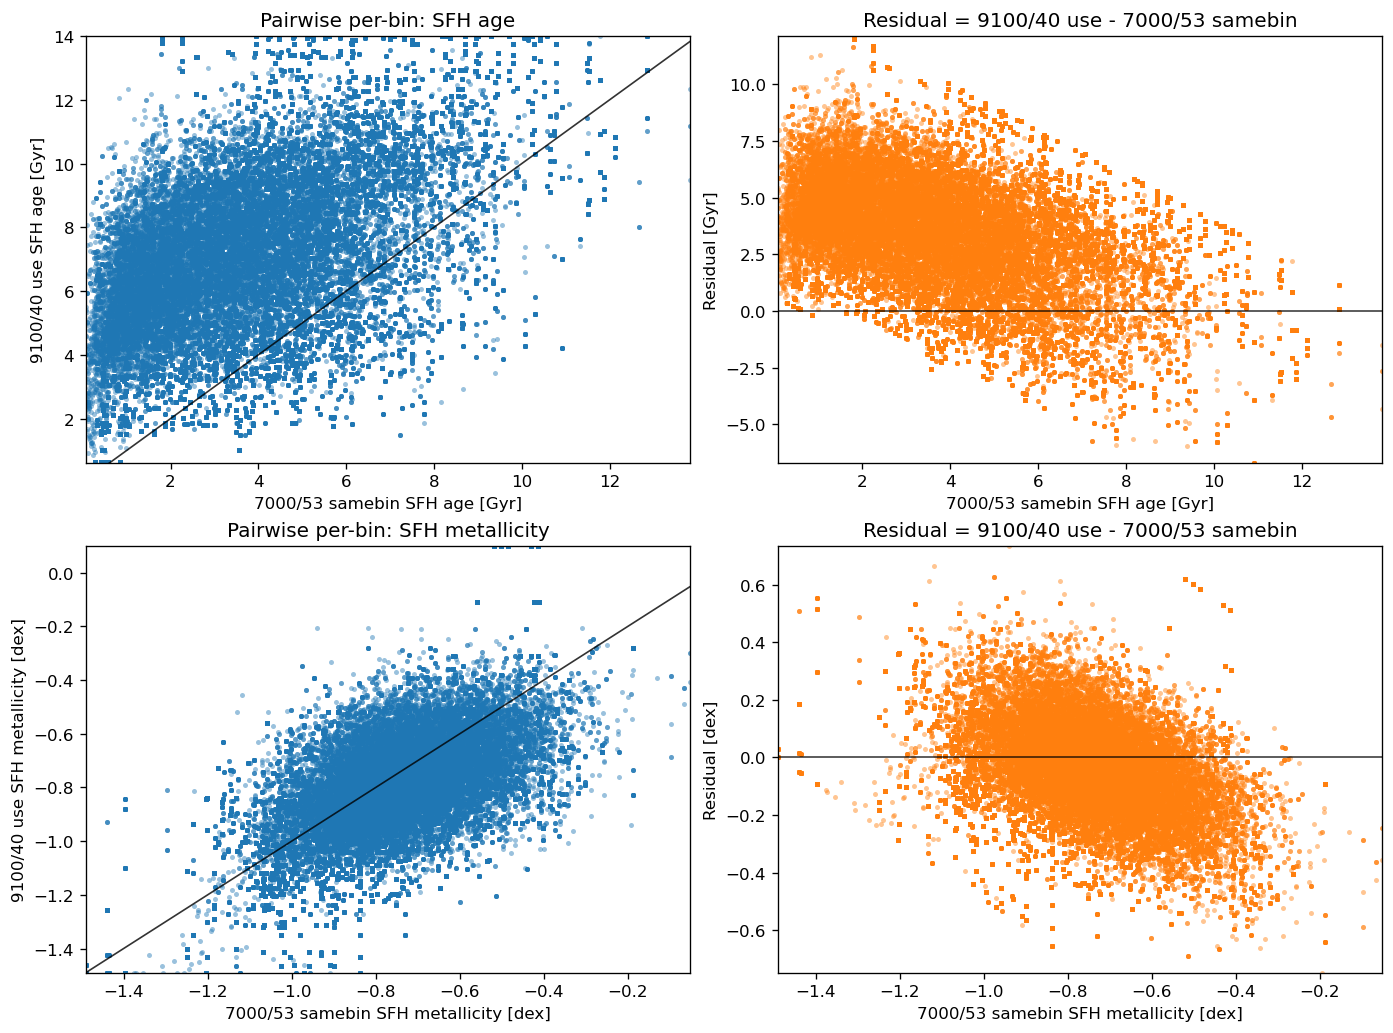

In [13]:
fig, axes = plt.subplots(len(SFH_MAP_PROPERTIES), 2, figsize=(11.5, 8.5), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(SFH_MAP_PROPERTIES.items()):
    table = sfh_map_tables[prop_key]
    x = table['ref'].to_numpy(dtype=float)
    y = table['test'].to_numpy(dtype=float)
    residual = table['residual'].to_numpy(dtype=float)

    ax = axes[row, 0]
    ax.scatter(x, y, s=9, alpha=0.45, linewidths=0, color='tab:blue')
    xlo, xhi = finite_limits(x)
    ylo, yhi = finite_limits(y)
    line_lo = min(xlo, ylo)
    line_hi = max(xhi, yhi)
    ax.plot([line_lo, line_hi], [line_lo, line_hi], color='black', lw=1.0, alpha=0.8)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_ylabel(f"{RUNS[TEST_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_title(f"Pairwise per-bin: {prop['label']}")

    ax = axes[row, 1]
    ax.axhline(0, color='black', lw=1.0, alpha=0.75)
    ax.scatter(x, residual, s=9, alpha=0.45, linewidths=0, color='tab:orange')
    xlo, xhi = finite_limits(x)
    ylo, yhi = finite_limits(residual)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_ylabel(f"Residual [{prop['unit']}]")
    ax.set_title(f"Residual = {RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}")

plt.show()

## Integrated Mass-Log Values

These values are parsed directly from each run's `mass_logs/<galaxy>.log`. The comparison column is `9100/40 use - 7000/53 samebin`.

In [14]:
INTEGRATED_METRIC_ROWS = [
    ('Total R-band magnitude (uncorrected)', 'total_R_mag_uncorrected_AB', 'mag AB'),
    ('Total R-band magnitude (corrected)', 'total_R_mag_corrected_AB', 'mag AB'),
    ('Total R-band luminosity', 'total_R_luminosity_log10_Lsun', 'log10(Lsun)'),
    ('Total stellar mass (R)', 'total_stellar_mass_log10_Msun', 'log10(Msun)'),
    ('Integrated stellar M/L_R', 'integrated_ML_R_Msun_per_Lsun', 'Msun/Lsun'),
]

integrated_rows = []
for label, key, unit in INTEGRATED_METRIC_ROWS:
    value_samebin = log_summary.loc[RUNS[REF_KEY]['label'], key]
    value_use = log_summary.loc[RUNS[TEST_KEY]['label'], key]
    integrated_rows.append({
        'quantity': label,
        RUNS[REF_KEY]['label']: value_samebin,
        RUNS[TEST_KEY]['label']: value_use,
        f"{RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}": value_use - value_samebin,
        'unit': unit,
    })

integrated_log_values = pd.DataFrame(integrated_rows)
display(integrated_log_values)


,quantity,7000/53 samebin,9100/40 use,9100/40 use - 7000/53 samebin,unit
0,Total R-band magnitude (uncorrected),11.8420,11.8420,0.0000,mag AB
1,Total R-band magnitude (corrected),11.3020,11.4450,0.1430,mag AB
2,Total R-band luminosity,9.7580,9.7010,-0.0570,log10(Lsun)
3,Total stellar mass (R),9.6200,9.7980,0.1780,log10(Msun)
4,Integrated stellar M/L_R,0.7279,1.2494,0.5215,Msun/Lsun


## Observation And Interpretation

### Observation

The `BINID` maps do not match exactly, so the pairwise statistics use `226609` common finite pixels rather than matched-bin rows. The residual convention throughout this notebook is `9100/40 use - 7000/53 samebin`. The two maps still share the same image grid, so the residual maps are direct pixel-level map differences.

For `E(B-V)`, the spatial pattern is broadly preserved but the `9100/40 use` run is lower overall. The correlation is `0.826`. The median value changes from `0.0249 mag` in `7000/53 samebin` to `0.0243 mag` in `9100/40 use`, giving a median residual of `-0.0115 mag`. The 16th to 84th percentile residual range is `-0.0532` to `0.0011 mag`, and the full residual range is `-0.2142` to `0.5024 mag`. Negative residuals occur in `142789` comparison points and positive residuals in `38129`.

For `LOGMASS_SURFACE_DENSITY`, the median changes from `7.0749 dex` to `7.2259 dex`, with a median residual of `0.1394 dex`. The correlation is `0.947` and the full residual range is `-0.5682` to `1.0576 dex`. Positive residuals occur in `185682` comparison points and negative residuals in `40918`.

The parsed mass logs show that the uncorrected total R-band magnitude is unchanged at `11.842 AB`. After extinction correction, `9100/40 use` is fainter by `0.143 mag`, corresponding to a total R-band luminosity change of `-0.057 dex`. The total stellar mass changes by `0.178 dex`, and the integrated `M/L_R` changes from `0.7279` to `1.2494 M_sun/L_sun`.

The SFH template grids match: `53` `LOGAGE` bins, `9` metallicity bins, and `1` `ALPHA` value. In the equal-bin-average weight grid, the mean linear age changes from `3.022 Gyr` to `6.822 Gyr`, and the weight fraction at ages `>= 8 Gyr` changes from `0.168` to `0.450`. The largest positive weight residual cell is at age `14.00 Gyr`, `METAL = -1.49`, with residual weight `0.1600`. The largest negative weight residual cell is at age `0.07 Gyr`, `METAL = -0.66`, with residual weight `-0.0718`.

The spatial `AGE` and `METAL` products provide the map-level view of the same SFH changes. The median age changes from `4.986 Gyr` to `10.354 Gyr`, with a median residual of `3.617 Gyr`; the age residual range is `-6.688` to `12.140 Gyr`. The median metallicity changes from `-0.8717 dex` to `-0.9836 dex`, with a median residual of `-0.1312 dex`.

### Interpretation

For NGC4383 the pattern is qualitatively similar to IC3392 but stronger in the mass direction. The `9100/40 use` solution has slightly lower dust, much older fitted ages, and a higher mass-to-light ratio. That older/higher-`M/L_R` solution more than compensates for the lower dust-corrected luminosity, so both the integrated stellar mass and most map pixels move upward in stellar mass surface density.

The useful point of the SFH-weight heatmap is that it separates a simple dust/luminosity change from a population-mixture change. The uncorrected R-band magnitude staying fixed shows that the input photometric scale is stable. The changes in corrected luminosity, stellar mass, and mass surface density therefore come from the coupled dust and SFH solution: lower fitted dust changes the extinction correction, while shifts in the age-metallicity weight distribution change `M/L_R`.

Because the NGC pairwise statistics use `common finite pixels` rather than matched spatial-bin rows, the scatter plots should be read as map-level comparisons across the shared image footprint. The residual maps are still the most direct spatial diagnostic. Any large local residuals should be checked against the binning maps before interpreting them as true localized SFH structure.

## Notes For Reading This Notebook

- The first figure is the requested 2x2 product-map view, with one shared colorbar per property row.
- Pairwise and residual scatter plots use one point per spatial bin.
- Residual maps use the image grids directly and show `9100/40 use - 7000/53 samebin`.
- The parsed mass-log table is included because integrated stellar mass and M/L can shift even when the maps look spatially similar.

In [15]:
# Optional exports if needed later.
# residual_summary.to_csv('NGC4383_SFH_mass_residual_summary_20260518.csv', index=False)
# log_summary.to_csv('NGC4383_mass_log_summary_20260518.csv')